# Accessible volumes: where the dye can be

A FRET distance is not a distance between residues. It is a distance between
two dyes, and each dye hangs off its residue on a linker that is long enough to
matter: an Alexa488 C1R linker reaches about 20 A. Whatever a model of the
protein says, the numbers a FRET experiment produces are numbers about where
the dyes were.

`IMP.bff` offers two models of "where the dye was".

* The **accessible volume** (AV) is a *geometric* model. The dye is a ball on a
  flexible tether; the AV is the set of positions that ball can occupy without
  running into the protein. It is a cloud of points, it costs milliseconds, and
  it carries no chemistry at all.
* The **explicit dye** is a *physical* model: a real, atomistic dye plus linker,
  placed on the residue in every conformer of a rotamer library and scored
  against the protein. It knows about atoms, energies and the dye's transition
  dipole.

This notebook is about the first of the two. The next notebook builds the
second at the same site and puts the two answers side by side.

**Structure.** hGBP1, human guanylate-binding protein 1, an interferon-induced
GTPase that changes shape when it hydrolyses GTP. The workshop carries a
coarse-grained recording of that open/closed transition: 58 frames of a
570-residue model, and `ws.hgbp1_state(frame)` writes any one of them out as a
PDB. Frames 0 and 57 are the two ends of the recorded path, and they play the
part the two crystal forms of a transporter would.

One thing about that file has to be said before any residue number is used.
Its chains `A` and `B` are **residue ranges**, 1-151 and 152-570, not two
protein copies. hGBP1 is one chain; whoever wrote the model split it in two for
bookkeeping. So a site is named by the chain letter that file gives it, and
"chain B residue 496" means residue 496 of the single hGBP1 molecule.

In [1]:
%matplotlib inline
import collections
import json
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
for candidate in (here, here / "doc" / "workshop", here.parent):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate))
        break
import workshop as ws
import IMP.bff as bff

n_frames = ws.hgbp1_n_frames()
LAST = n_frames - 1
start = ws.hgbp1_state(0)
end = ws.hgbp1_state(LAST)
print("recorded transition: %d frames; its two ends are frame 0 and frame %d"
      % (n_frames, LAST))

residues = collections.defaultdict(list)
with_cb = collections.Counter()
for line in start.read_text().splitlines():
    if line.startswith("ATOM"):
        name = line[12:16].strip()
        if name == "CA":
            residues[line[21]].append(int(line[22:26]))
        elif name == "CB":
            with_cb[line[21]] += 1
for chain, resi in sorted(residues.items()):
    print("  chain %s: residues %4d-%4d (%3d residues, %3d of them with a CB)"
          % (chain, min(resi), max(resi), len(resi), with_cb[chain]))
print("  -> one 570-residue molecule split into two labelled ranges, not two copies")

# The labelling site pair this notebook works with. Both positions are real
# ones: they appear in the published hGBP1 FRET network shipped with IMP.bff.
DONOR = ("B", 496, "Alexa488")
ACCEPTOR = ("B", 344, "Alexa647")
for name, pdb in (("frame  0", start), ("frame %2d" % LAST, end)):
    separation = np.linalg.norm(ws.ca_position(pdb, *DONOR[:2])
                                - ws.ca_position(pdb, *ACCEPTOR[:2]))
    print("%s  C-alpha separation of %s%d and %s%d: %5.1f A"
          % (name, DONOR[0], DONOR[1], ACCEPTOR[0], ACCEPTOR[1], separation))

recorded transition: 58 frames; its two ends are frame 0 and frame 57
  chain A: residues    1- 151 (151 residues, 138 of them with a CB)
  chain B: residues  152- 570 (419 residues, 406 of them with a CB)
  -> one 570-residue molecule split into two labelled ranges, not two copies
frame  0  C-alpha separation of B496 and B344:  30.6 A
frame 57  C-alpha separation of B496 and B344:  22.9 A


### The molecule, moving

Before any number, the thing itself. The panel below plays the recorded
transition in the browser: every fourth frame of the trajectory, as a backbone
trace, stepping through the models of one multi-model PDB. Drag to rotate.

This is worth ten seconds of watching, because everything below depends on it.
The two labelling sites are carried on parts of the molecule that move relative
to each other, which is the only reason a dye pair on them reports anything at
all.

In [2]:
frames = ws.hgbp1_frames(every=4)
print("%d frames in the animation, %d atoms each"
      % (len(frames), sum(1 for line in frames[0].splitlines() if line.startswith("ATOM"))))
ws.show([{"title": "hGBP1: the recorded open/closed transition, every 4th frame",
          "structure": ws.morph_pdb(frames), "animate_models": True,
          "frame_ms": 300, "clouds": []}], height=440)

15 frames in the animation, 570 atoms each


## 1. What an accessible volume is, and what it assumes

`ws.av` wraps one call, `IMP.bff.get_av_from_pdb`. You give it a structure, a
site (chain, residue, attachment atom -- `CB` by convention for AVs), and four
numbers that describe the dye: how far the linker reaches, how thick it is, how
big the dye itself is, and how finely to grid the search. The search grows
outward from the attachment atom along paths that stay clear of the protein,
and keeps every grid point the dye can reach.

What comes back is a `ProbeAccessibleVolume`: a weighted point cloud. Nothing
about it is an energy. A point is in or out.

In [3]:
av_donor = ws.av(start, *DONOR)
av_acceptor = ws.av(start, *ACCEPTOR)


def cloud_stats(volume, pdb, chain, resi):
    points = ws.av_points(volume)
    xyz, w = points[:, :3], points[:, 3]
    mean = (xyz * w[:, None]).sum(0) / w.sum()
    extent = np.sqrt((((xyz - mean) ** 2).sum(1) * w).sum() / w.sum())
    attach = ws.ca_position(pdb, chain, resi)
    return dict(n=volume.get_n_points(), mean=mean, extent=extent,
                offset=float(np.linalg.norm(mean - attach)))


for name, volume, site in (("donor  ", av_donor, DONOR), ("acceptor", av_acceptor, ACCEPTOR)):
    s = cloud_stats(volume, start, site[0], site[1])
    print("%s %s%-4d %-9s %5d points   RMS extent %5.2f A   mean position %5.2f A from CA"
          % (name, site[0], site[1], site[2], s["n"], s["extent"], s["offset"]))

donor   B496  Alexa488   3670 points   RMS extent 13.44 A   mean position  8.67 A from CA
acceptor B344  Alexa647   3895 points   RMS extent 13.65 A   mean position 11.84 A from CA


The cloud is wide -- about 13 A RMS about its own mean -- and its mean position
sits between eight and twelve Angstrom from the C-alpha it hangs on. That is
the whole reason the AV exists: the difference between "residue 496" and "the
dye on residue 496" is larger than the precision a good FRET measurement
claims, and larger than most of the structural differences anyone wants to
resolve.

**The assumption.** Every distance computed from an AV treats the cloud as a
probability density over dye positions: the dye visits everything it can reach,
and visits it *equally*. `ws.av` leaves the weights uniform, which is the FPS
convention. Three things this assumes, each of which can fail:

1. **No energetics.** A real dye is attracted to hydrophobic patches and
   repelled from like charges; the charged Alexa dyes are not immune to this.
   The AV gives a sticky surface pocket the same weight as open solvent.
2. **Full sampling.** The averaging is over the whole cloud, which is only
   right if the dye explores all of it within the donor lifetime (nanoseconds).
   A dye trapped in one lobe of a two-lobed volume reports that lobe, not the
   average.
3. **Isotropic orientation.** kappa-squared = 2/3 is assumed everywhere. The AV
   cloud carries positions only -- there is no transition dipole in it, so
   there is nothing else it could assume.

The explicit dye of the next notebook relaxes the first and the third. Nothing
relaxes the second.

## 2. AV1 and AV3 at the same site

An **AV1** models the dye as a single sphere of one radius. An **AV3** models it
as three radii -- the dye is not a ball, it is a flat, elongated chromophore,
and an AV3 asks whether an ellipsoid of those half-axes fits, in any
orientation, at each candidate position. `ws.av(..., av3=True)` switches
between them; the radii come from `ws.DYES`.

The caution the helper documents, and it matters: **an AV1 radius is not the
first AV3 radius.** Alexa647's AV3 radii are 11.0 / 3.0 / 1.5 A -- an 11 A
half-length along the long axis of a flat dye. Its AV1 radius is 3.5 A. Feeding
the 11 to an AV1 asks for a sphere of radius 11 to fit beside the site.

In [4]:
rows = []
for av3 in (False, True):
    d = ws.av(start, *DONOR, av3=av3)
    a = ws.av(start, *ACCEPTOR, av3=av3)
    rows.append((
        "AV3" if av3 else "AV1",
        d.get_n_points(), a.get_n_points(),
        cloud_stats(d, start, *DONOR[:2])["extent"],
        cloud_stats(a, start, *ACCEPTOR[:2])["extent"],
        ws.rda(d, a), ws.rda_e(d, a),
    ))

print("model   pts(D)  pts(A)   ext(D)  ext(A)   <R_DA>   <R_DA>_E")
for r in rows:
    print("%-6s %7d %7d   %6.2f  %6.2f   %6.2f    %6.2f" % r)
print()
print("radii used -- Alexa488 AV1 %.1f, AV3 %s" % (
    ws.DYES["Alexa488"]["av1_radius"], ws.DYES["Alexa488"]["av3_radii"]))
print("              Alexa647 AV1 %.1f, AV3 %s" % (
    ws.DYES["Alexa647"]["av1_radius"], ws.DYES["Alexa647"]["av3_radii"]))

model   pts(D)  pts(A)   ext(D)  ext(A)   <R_DA>   <R_DA>_E
AV1       3670    3895    13.44   13.65    48.49     49.04
AV3       4352    4475    13.34   13.63    48.65     49.16

radii used -- Alexa488 AV1 3.5, AV3 (5.0, 4.5, 1.5)
              Alexa647 AV1 3.5, AV3 (11.0, 3.0, 1.5)


In [5]:
# What happens if you mistake the AV3 long half-axis for an AV1 radius. Two
# sites: the acceptor of this notebook, and one where the mistake is fatal.
geometry = ws.DYES["Alexa647"]

def av1_with_radius(pdb, chain, resi, radius):
    return bff.get_av_from_pdb(
        str(pdb), chain, int(resi), "CB",
        geometry["linker_length"], geometry["linker_width"],
        radius, 0.0, 0.0, 1.5, 5.0)

for chain, resi in ((ACCEPTOR[0], ACCEPTOR[1]), ("B", 356)):
    correct = ws.av(start, chain, resi, "Alexa647")
    wrong = av1_with_radius(start, chain, resi, geometry["av3_radii"][0])
    print("%s%-4d  correct AV1 (r = %.1f A): %5d points"
          % (chain, resi, geometry["av1_radius"], correct.get_n_points()))
    print("        the 11.0 A sphere      : %5d points" % wrong.get_n_points())
    if wrong.get_n_points():
        print("        <R_DA>_E from it: %6.2f A   (from the correct AV1: %6.2f A)"
              % (ws.rda_e(av_donor, wrong), ws.rda_e(av_donor, correct)))
    else:
        print("        no points at all -- there is no distance to compute here")
    print()

# ws.av refuses to hand back a volume with no points, rather than a distance of zero.
try:
    ws.av(start, "B", 356, "Alexa647", av3=False)
    print("ws.av at B356 with the correct radius: fine, the site is not the problem")
except ws.EmptyVolume as error:
    print("raised:", error)

B344   correct AV1 (r = 3.5 A):  3895 points


        the 11.0 A sphere      :   961 points
        <R_DA>_E from it:  52.20 A   (from the correct AV1:  49.04 A)

B356   correct AV1 (r = 3.5 A):  1860 points
        the 11.0 A sphere      :     0 points
        no points at all -- there is no distance to compute here

ws.av at B356 with the correct radius: fine, the site is not the problem


Two different failures, and only one of them announces itself.

At B344 the 11 A sphere still finds room, but the cloud it finds is a different
object from the AV1 above -- a quarter of the positions, pushed further from the
protein -- and the distance it gives is not comparable with anything. Nothing
raises, nothing warns; you get a number, and the number is wrong.

At B356 the same mistake returns nothing at all. That is the honest failure, and
it is why `ws.av` raises `EmptyVolume` instead of handing back a cloud whose
distances are all zero. An empty volume is not a distance of zero. It is the
absence of a distance, and a network that quietly fills it with zero is worse
than a network with a hole in it.

The AV1/AV3 difference at *this* pair is small, under two tenths of an Angstrom
in both reductions, because both sites are open and the dye has room in every
orientation. That is the usual outcome. AV3 earns its extra cost at crowded
sites, where orientation decides whether the dye fits.

## 3. One pair, one distribution, three numbers

Two clouds do not give a distance. They give a *distribution* of distances:
take every donor position against every acceptor position, weighted. Everything
a FRET model reports is a different reduction of that distribution, and the
reductions do not agree with each other.

* **`<R_DA>`** -- the plain mean of the distribution. A geometric quantity.
* **`<R_DA>_E`** -- the distance whose efficiency equals the *mean efficiency*
  of the distribution. This is what a FRET experiment measures, because the
  experiment averages rates, not distances.
* **`E`** -- the mean transfer efficiency itself.

They differ because `E(R) = 1 / (1 + (R/R0)^6)` is strongly curved. Averaging a
curved function is not the same as evaluating it at the average, and the size
*and the sign* of the difference follow from which way the curve bends over the
range the distribution covers.

In [6]:
axis, p = ws.distance_distribution(av_donor, av_acceptor)
p = p / p.sum()
E_of_R = 1.0 / (1.0 + (axis / ws.R0) ** 6)

mean_hist = float((axis * p).sum())
sigma_hist = float(np.sqrt((p * (axis - mean_hist) ** 2).sum()))
mean_exact = ws.rda(av_donor, av_acceptor)
rdae = ws.rda_e(av_donor, av_acceptor)
E_mean = ws.efficiency(rdae)              # exact by construction of <R_DA>_E

# E(R) has an inflection: below it the curve is concave, above it convex.
R_inflection = ws.R0 * (5.0 / 7.0) ** (1.0 / 6.0)

print("R0 used here                       %6.2f A" % ws.R0)
print("inflection of E(R)                 %6.2f A   (= R0 * (5/7)^(1/6))" % R_inflection)
print("<R_DA>          (mean of p(R))     %6.2f A   (histogram: %.2f, sigma %.2f)"
      % (mean_exact, mean_hist, sigma_hist))
print("<R_DA>_E        (FRET-averaged)    %6.2f A" % rdae)
print("difference, <R_DA>_E - <R_DA>      %+6.2f A" % (rdae - mean_exact))
print()
print("E from <R_DA>_E (this is <E>)      %6.4f" % E_mean)
print("E evaluated at <R_DA>              %6.4f" % ws.efficiency(mean_exact))
print("error if you use <R_DA> as if it were the measured distance: %+.4f in E"
      % (E_mean - ws.efficiency(mean_exact)))

R0 used here                        52.00 A
inflection of E(R)                  49.16 A   (= R0 * (5/7)^(1/6))
<R_DA>          (mean of p(R))      48.49 A   (histogram: 48.00, sigma 9.84)
<R_DA>_E        (FRET-averaged)     49.04 A
difference, <R_DA>_E - <R_DA>       +0.55 A

E from <R_DA>_E (this is <E>)      0.5871
E evaluated at <R_DA>              0.6035
error if you use <R_DA> as if it were the measured distance: -0.0164 in E


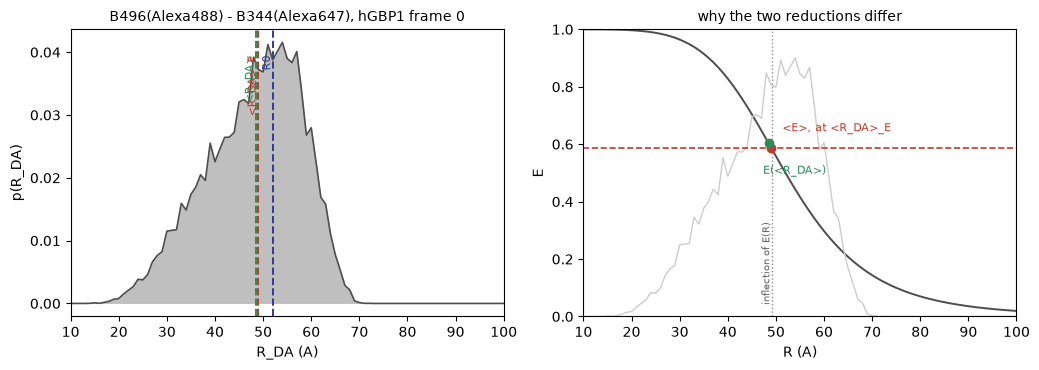

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax1.fill_between(axis, p, color="0.75", step=None, lw=0)
ax1.plot(axis, p, color="0.3", lw=1.2)
for value, colour, label in ((mean_exact, "#2E8B57", "<R_DA>"),
                             (rdae, "#C0392B", "<R_DA>_E"),
                             (ws.R0, "#2C3E90", "R0")):
    ax1.axvline(value, color=colour, lw=1.4, ls="--")
    ax1.annotate(label, (value, p.max() * 0.95), rotation=90, fontsize=8,
                 color=colour, ha="right", va="top")
ax1.set_xlabel("R_DA (A)")
ax1.set_ylabel("p(R_DA)")
ax1.set_xlim(10, 100)
ax1.set_title("%s%d(Alexa488) - %s%d(Alexa647), hGBP1 frame 0"
              % (DONOR[0], DONOR[1], ACCEPTOR[0], ACCEPTOR[1]), fontsize=10)

ax2.plot(axis, E_of_R, color="0.3", lw=1.4, label="E(R)")
ax2.plot(axis, p / p.max() * 0.9, color="0.8", lw=1.0, label="p(R), scaled")
ax2.axvline(R_inflection, color="0.55", lw=1.0, ls=":")
ax2.annotate("inflection of E(R)", (R_inflection, 0.04), rotation=90, fontsize=7.5,
             color="0.4", ha="right", va="bottom")
ax2.axhline(E_mean, color="#C0392B", lw=1.2, ls="--")
ax2.plot([rdae], [E_mean], "o", color="#C0392B", ms=6)
ax2.plot([mean_exact], [ws.efficiency(mean_exact)], "o", color="#2E8B57", ms=6)
ax2.annotate("<E>, at <R_DA>_E", (rdae, E_mean), textcoords="offset points",
             xytext=(8, 12), fontsize=8, color="#C0392B")
ax2.annotate("E(<R_DA>)", (mean_exact, ws.efficiency(mean_exact)),
             textcoords="offset points", xytext=(-4, -22), fontsize=8, color="#2E8B57")
ax2.set_xlabel("R (A)")
ax2.set_ylabel("E")
ax2.set_xlim(10, 100)
ax2.set_ylim(0, 1)
ax2.set_title("why the two reductions differ", fontsize=10)
fig.tight_layout()
plt.show()

Read the right-hand panel. `E(R)` bends one way below its inflection at
`R0 * (5/7)^(1/6)` = 49.2 A and the other way above it. This pair sits almost
exactly on that point, and the distribution is wide enough to straddle it, so
the two reductions land within about half an Angstrom of each other -- with
`<R_DA>_E` on the *long* side of `<R_DA>`, not the short side.

That is worth a moment, because the usual statement of this lesson -- "the
FRET-averaged distance is shorter than the mean distance" -- is only true above
the inflection. It is a statement about a regime, not an identity. The next cell
shows both signs at once, using every pair that can be made from the published
hGBP1 labelling positions on this structure.

In [8]:
# The published network's labelling positions, on the residue ranges this
# topology uses: 18 falls in chain A, the rest in chain B.
LABEL_SITES = [18, 254, 344, 481, 496, 525, 540]
chain_of = lambda resi: "A" if resi <= 151 else "B"

print("The sign of <R_DA>_E - <R_DA> follows the curvature of E(R):")
print("  pair      <R_DA>   <R_DA>_E   difference")
rows = []
for i, a in enumerate(LABEL_SITES):
    for b in LABEL_SITES[i + 1:]:
        d = ws.av(start, chain_of(a), a, "Alexa488")
        c = ws.av(start, chain_of(b), b, "Alexa647")
        rows.append((a, b, ws.rda(d, c), ws.rda_e(d, c)))
for a, b, m, e in sorted(rows, key=lambda r: r[2]):
    marker = "<-- below the inflection" if m < R_inflection else ""
    print("  %3d-%-3d %8.2f %10.2f %11.2f   %s" % (a, b, m, e, e - m, marker))

below = [r for r in rows if r[2] < R_inflection]
above = [r for r in rows if r[2] >= R_inflection]
print()
print("%d pairs below %.1f A: <R_DA>_E is longer in %d of them"
      % (len(below), R_inflection, sum(1 for r in below if r[3] > r[2])))
print("%d pairs above %.1f A: <R_DA>_E is shorter in %d of them"
      % (len(above), R_inflection, sum(1 for r in above if r[3] < r[2])))

The sign of <R_DA>_E - <R_DA> follows the curvature of E(R):
  pair      <R_DA>   <R_DA>_E   difference


  481-496    29.87      34.50        4.62   <-- below the inflection
  525-540    31.17      35.91        4.74   <-- below the inflection
   18-344    44.14      45.84        1.69   <-- below the inflection
  344-496    48.62      49.18        0.55   <-- below the inflection
  496-525    49.33      49.51        0.18   
   18-254    49.57      49.83        0.26   
  344-525    50.98      50.80       -0.19   
   18-525    56.66      55.12       -1.53   
  344-481    56.67      55.44       -1.24   
  254-540    60.61      58.24       -2.37   
   18-540    63.22      61.02       -2.20   
  254-525    63.59      60.85       -2.75   
  481-525    68.42      65.20       -3.22   
  344-540    71.03      67.34       -3.69   
  496-540    71.15      67.07       -4.08   
  254-344    73.78      69.54       -4.24   
   18-496    77.48      72.42       -5.06   
  254-496    82.67      78.05       -4.62   
   18-481    84.88      79.08       -5.80   
  254-481    86.21      79.99       -6.22   
  48

The table sorts itself, almost. Every pair whose mean distance is below the
inflection has a FRET-averaged distance that is *longer*; nearly every pair
above has one that is shorter; and the gap grows with the width of the
distribution and with the distance from the inflection, reaching six Angstrom
at the long pairs.

The two exceptions are the point rather than a blemish on it. 496-525 and
18-254 sit half an Angstrom above the inflection and still come out on the long
side, because what decides the sign is not where the mean of `p(R_DA)` sits but
how the curvature is weighted across the whole ten-Angstrom-wide distribution.
A rule of thumb stated on the mean alone will get the sign wrong exactly where
the effect is smallest, which is where nobody checks.

The practical consequence is not the sign but the discipline. When a model is
scored against a measurement, both sides must be the same reduction of the same
distribution. `IMP.bff` distance restraints carry a `distance_type` field for
exactly this reason, and the published hGBP1 network shipped with the package
declares `RDAMean` on all 68 of its entries. A restraint file that does not say
which number it holds is not usable.

## 4. See it

Tables are one thing. The point of the Mol* view is that an accessible volume
is a *shape*, attached to a place on the fold, and that the shape moves when
the protein does.

The viewer loads Mol* from a CDN, so the cell below needs internet access from
your **browser**. Every number above is already computed and unaffected if it
does not load.

Two panels: the donor volume (green, Alexa488 on B496) and the acceptor volume
(red, Alexa647 on B344), at the two ends of the recorded transition. The
left-hand panel turns on its own so you can see the clouds from every side
without touching it; drag either panel to take over.

In [9]:
def cloud_panel(pdb, title, spin=False):
    clouds = []
    for chain, resi, dye, colour in (
            DONOR + (ws.DONOR_COLOUR,), ACCEPTOR + (ws.ACCEPTOR_COLOUR,)):
        volume = ws.av(pdb, chain, resi, dye)
        clouds.append({"pdb": ws.av_pdb(volume, max_points=900), "colour": colour,
                       "label": "%s%d %s" % (chain, resi, dye)})
    return {"title": title, "structure": ws.protein_for_view(pdb),
            "clouds": clouds, "spin": spin}


ws.show([
    cloud_panel(start, "frame 0: AV1 clouds at B496 (donor) and B344 (acceptor)", spin=True),
    cloud_panel(end, "frame %d: the same two sites, other end of the transition" % LAST),
], height=470)

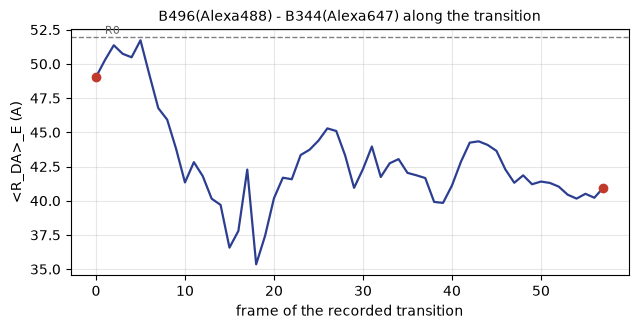

frame  0: <R_DA>_E 49.04 A, E 0.587
frame 57: <R_DA>_E 40.95 A, E 0.807
range over the path: 35.35 to 51.72 A


In [10]:
# What the picture is worth in numbers: the pair over the whole trajectory.
track = []
for f in range(n_frames):
    pdb = ws.hgbp1_state(f)
    track.append(ws.rda_e(ws.av(pdb, *DONOR), ws.av(pdb, *ACCEPTOR)))
track = np.asarray(track)

fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(np.arange(n_frames), track, color="#2C3E90", lw=1.6)
ax.plot([0, LAST], [track[0], track[LAST]], "o", color="#C0392B", ms=6)
ax.axhline(ws.R0, color="0.5", lw=1.0, ls="--")
ax.annotate("R0", (1, ws.R0), fontsize=8, color="0.4", va="bottom")
ax.set_xlabel("frame of the recorded transition")
ax.set_ylabel("<R_DA>_E (A)")
ax.set_title("B496(Alexa488) - B344(Alexa647) along the transition", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

print("frame  0: <R_DA>_E %5.2f A, E %.3f" % (track[0], ws.efficiency(track[0])))
print("frame %2d: <R_DA>_E %5.2f A, E %.3f" % (LAST, track[LAST], ws.efficiency(track[LAST])))
print("range over the path: %.2f to %.2f A" % (track.min(), track.max()))

## 5. What the accessible volume is for

The AV is fast, it needs nothing but a structure and four numbers per dye, and
it is the label model almost all integrative modelling with FRET runs on. That
is a defensible choice. `IMP.bff` can rebuild AVs inside a sampling loop, which
no atomistic label model can match, and the alternative to a fast approximate
label model is usually no label model at all -- C-alpha distances, which are
wrong by the ten Angstrom the first section measured.

What the AV costs you is written into its three assumptions. It cannot see a
dye that sticks, it has no transition dipole so it cannot tell you anything
about kappa-squared, and the *width* of the distribution it produces is an
artefact of the search rather than a physical spread -- so a model that fits a
distance distribution to a lifetime decay is using a number the AV is not
entitled to.

Two diagnostics are cheap and routinely skipped:

* **An empty or tiny cloud is not a short distance.** `ws.av` raises
  `EmptyVolume`; if you call `IMP.bff.get_av_from_pdb` directly, check
  `get_n_points()` yourself. Section 2 showed both the loud failure and the
  quiet one.
* **The radii belong to the model.** An AV1 takes its own radius and an AV3 its
  own three. Mixing them produces a cloud that is not wrong in any way the code
  can detect.

The next notebook takes the same site pair, places the real dye on it as an
explicit rotamer ensemble, and asks how much of this the geometry was getting
right.